In [23]:
import numpy as np
from torchvision import datasets
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp
import cv2
import os
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import seaborn as sns
from matplotlib.patches import Patch


In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),

    A.HorizontalFlip(p=0.1),
    A.VerticalFlip(p=0.1),

    A.RandomBrightnessContrast(p=0.1),

    # Gaussian noise
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),

    # Random black patches / missing regions
    # A.CoarseDropout(
    #     num_holes_range=(1, 8),
    #     hole_height_range=(16, 48),
    #     hole_width_range=(16, 48),
    #     fill=0,
    #     p=0.3
    # ),

    A.Normalize(),
    ToTensorV2()
])

In [3]:
val_transform = A.Compose([
    A.Resize(256, 256), # Added Resize to ensure consistent image dimensions
    A.Normalize(),
    ToTensorV2()
])

In [4]:
class VOCSegAlbumentations:
    def __init__(self, root, year, image_set, transform=None):
        self.dataset = datasets.VOCSegmentation(
            root=root,
            year=year,
            image_set=image_set,
            download=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        image = np.array(image)
        mask = np.array(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()


In [5]:
train_dataset = VOCSegAlbumentations(
    root="./data",
    year="2012",
    image_set="train",
    transform=train_transform
)


100%|██████████| 2.00G/2.00G [06:12<00:00, 5.36MB/s] 


In [6]:
validate_dataset= VOCSegAlbumentations(
    root="./data",
    year="2012",
    image_set="val",
    transform=val_transform # Use the new validation-specific transform
)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(validate_dataset, batch_size=32, shuffle=True)

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None, reduction='mean', ignore_index=255):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index
        self.alpha = alpha

    def forward(self, inputs, targets):

        N, C, H, W = inputs.shape

        inputs = inputs.permute(0, 2, 3, 1).reshape(-1, C)
        targets = targets.view(-1)

        valid = targets != self.ignore_index
        inputs = inputs[valid]
        targets = targets[valid]

        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)

        targets_one_hot = F.one_hot(targets, C).float()

        pt = (probs * targets_one_hot).sum(dim=1).clamp(1e-6, 1.0)
        log_pt = (log_probs * targets_one_hot).sum(dim=1)

        focal_weight = (1 - pt) ** self.gamma

        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            alpha_t = alpha[targets]
            loss = -alpha_t * focal_weight * log_pt
        else:
            loss = -focal_weight * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [9]:


class DiceCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, ignore_index=255):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="multiclass", ignore_index=ignore_index)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index)
        self.dice_weight = dice_weight
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        dice = self.dice(logits, targets)
        return self.dice_weight * dice + (1 - self.dice_weight) * ce


class DiceFocalLoss(nn.Module):
    def __init__(self, weight=0.3, alpha=None, gamma=2, ignore_index=255):
        super().__init__()
        self.dice = smp.losses.DiceLoss(mode="multiclass", ignore_index=ignore_index)
        self.focal = FocalLoss(gamma=gamma,alpha=alpha, ignore_index=ignore_index)
        self.weight = weight
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        dice = self.dice(logits, targets)
        focal = self.focal(logits, targets)
        return self.weight* dice + (1 - self.weight) * focal

In [10]:
def dice_score(preds, targets, num_classes=21, eps=1e-6):
    preds = torch.argmax(preds, dim=1)

    dice = 0.0
    count = 0

    for cls in range(1, num_classes):

        pred_mask = (preds == cls)
        true_mask = (targets == cls)

        intersection = (pred_mask & true_mask).sum().float()
        union = pred_mask.sum().float() + true_mask.sum().float()

        if union > 0:
            dice += (2 * intersection + eps) / (union + eps)
            count += 1

    return dice / max(count, 1)

In [11]:
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device).long()

            outputs = model(images)

            loss = loss_fn(outputs, masks)
            total_loss += loss.item()

            total_dice += dice_score(outputs, masks).item()

    return total_loss / len(loader), total_dice / len(loader)

In [12]:
num_classes = 21
ignore_index = 255

class_counts = torch.zeros(num_classes, dtype=torch.long)

print("Analyzing mask distribution...")

for _, masks in train_loader:

    masks = masks.view(-1)

    masks = masks[masks != ignore_index]

    counts = torch.bincount(
        masks,
        minlength=num_classes
    )

    class_counts += counts

total_pixels = class_counts.sum()

print("\nClass distribution (fractions):")

fractions = []

for class_id in range(num_classes):

    fraction = (
        class_counts[class_id].item()
        / total_pixels.item()
    )

    fractions.append(fraction)

    print(f"Class {class_id}: {fraction:.6f}")



Analyzing mask distribution...

Class distribution (fractions):
Class 0: 0.734533
Class 1: 0.007444
Class 2: 0.002982
Class 3: 0.008700
Class 4: 0.006205
Class 5: 0.006095
Class 6: 0.017877
Class 7: 0.014406
Class 8: 0.027084
Class 9: 0.011584
Class 10: 0.008493
Class 11: 0.013128
Class 12: 0.017025
Class 13: 0.009377
Class 14: 0.011475
Class 15: 0.048346
Class 16: 0.006541
Class 17: 0.008947
Class 18: 0.014580
Class 19: 0.016063
Class 20: 0.009114


In [13]:
fractions = torch.tensor(fractions)

eps = 1e-6

alpha = 1.0 / torch.sqrt(fractions + eps)

alpha = alpha / alpha.sum()

print(alpha)

tensor([0.0058, 0.0581, 0.0918, 0.0537, 0.0636, 0.0642, 0.0375, 0.0418, 0.0305,
        0.0466, 0.0544, 0.0437, 0.0384, 0.0518, 0.0468, 0.0228, 0.0620, 0.0530,
        0.0415, 0.0395, 0.0525])


In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = smp.Unet(
    encoder_name="tu-convnext_base",   
    encoder_weights="imagenet",
    in_channels=3,
    classes=21
)

for param in model.encoder.parameters():
    param.requires_grad = False
model.to(device)

loss_fn = DiceFocalLoss(weight=0.4, alpha=None,gamma=2)

# loss_fn= FocalLoss(gamma=2,alpha = alpha)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

optimizer = torch.optim.Adam(
    model.decoder.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Using device: cuda


In [15]:

# num_epochs = 100
# unfrozen=0

# best_val_dice = 0
# train_losses = []
# train_dices = []
# val_losses = []
# val_dices = []
# start_epoch = 0

# checkpoint_path = "checkpoint_epoch_unet.pth"

# if os.path.exists(checkpoint_path):
#     checkpoint = torch.load(checkpoint_path)
#     model.load_state_dict(checkpoint["model_state"])
#     start_epoch = checkpoint["epoch"] + 1
#     if start_epoch>=50:
#         optimizer = torch.optim.Adam([
#             {
#                 "params": model.encoder.parameters(),
#                 "lr": 1e-5   # very small LR
#             },
#             {
#                 "params": model.decoder.parameters(),
#                 "lr": 1e-4
#             }
#         ])

#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer,
#             mode='min',
#             factor=0.1,
#             patience=3
#         )

#     optimizer.load_state_dict(checkpoint["optimizer_state"])
#     scheduler.load_state_dict(checkpoint["scheduler_state"])
#     start_epoch = checkpoint["epoch"] + 1
#     best_val_dice = checkpoint["val_dice"]
#     train_losses = checkpoint["train_losses"]
#     train_dices = checkpoint["train_dices"]
#     val_losses = checkpoint["val_losses"]
#     val_dices = checkpoint["val_dices"]
#     print(f"Resuming training from epoch {start_epoch} with best_val_dice: {best_val_dice:.4f}")
# else:
#     print("No checkpoint found, starting training from scratch.")

# for epoch in range(start_epoch, start_epoch+num_epochs):

#     if epoch >=50 and unfrozen==0:
#         unfrozen=1
#         print("Unfreezing encoder...")

#         for param in model.encoder.parameters():
#             param.requires_grad = True

#         # New optimizer with different learning rates
#         optimizer = torch.optim.Adam([
#             {
#                 "params": model.encoder.parameters(),
#                 "lr": 1e-5   # very small LR
#             },
#             {
#                 "params": model.decoder.parameters(),
#                 "lr": 1e-3
#             }
#         ])

#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer,
#             mode='min',
#             factor=0.1,
#             patience=3
#         )
#         optimizer.load_state_dict(checkpoint["optimizer_state"])
#         scheduler.load_state_dict(checkpoint["scheduler_state"])

#     model.train()
#     train_loss = 0
#     train_dice = 0
#     loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{start_epoch+num_epochs}", leave=True)


#     for images, masks in loop:

#         images = images.to(device)
#         masks = masks.to(device).long()
#         outputs = model(images)
        

#         loss = loss_fn(outputs, masks)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()
#         train_dice += dice_score(outputs, masks).item()

#     train_loss /= len(train_loader)
#     train_dice /= len(train_loader)
#     train_losses.append(train_loss)
#     train_dices.append(train_dice)

#     val_loss, val_dice = evaluate(model, val_loader, loss_fn, device)
#     val_losses.append(val_loss)
#     val_dices.append(val_dice)

#     # Step the scheduler based on validation loss
#     scheduler.step(val_loss)

#     print(f"\nEpoch {epoch+1}/{start_epoch+num_epochs}")
#     print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
#     print(f"Val Loss:   {val_loss:.4f}, Val Dice:   {val_dice:.4f}")

#     checkpoint = {
#         "epoch": epoch,
#         "model_state": model.state_dict(),
#         "optimizer_state": optimizer.state_dict(),
#         "scheduler_state": scheduler.state_dict(),
#         "val_dice": val_dice,
#         "train_losses": train_losses,
#         "train_dices": train_dices,
#         "val_losses": val_losses,
#         "val_dices": val_dices
#     }

#     if val_dice > best_val_dice:
#         best_val_dice = val_dice
#         torch.save(checkpoint, f"checkpoint_epoch_unet.pth")
#         torch.save(model.state_dict(), "best_model.pth")
#         print("Saved best model")

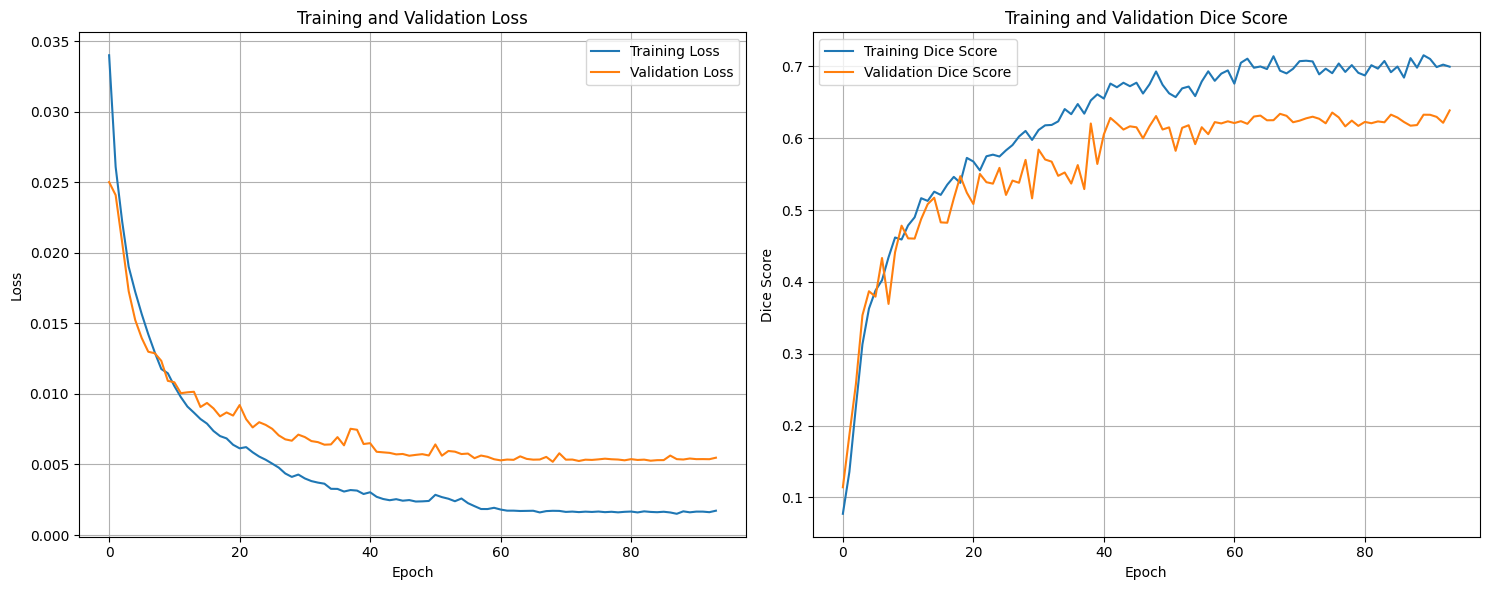

In [19]:
checkpoint_path='checkpoints/checkpoint_epoch_unet_convnext_g2_a_w0_0_ed.pth'
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint["model_state"])
start_epoch = checkpoint["epoch"] + 1
if start_epoch>=60:
    optimizer = torch.optim.Adam([
        {
            "params": model.encoder.parameters(),
            "lr": 1e-5   # very small LR
        },
        {
            "params": model.decoder.parameters(),
            "lr": 1e-4
        }
    ])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=3
    )

optimizer.load_state_dict(checkpoint["optimizer_state"])
scheduler.load_state_dict(checkpoint["scheduler_state"])
start_epoch = checkpoint["epoch"] + 1
best_val_dice = checkpoint["val_dice"]
train_losses = checkpoint["train_losses"]
train_dices = checkpoint["train_dices"]
val_losses = checkpoint["val_losses"]
val_dices = checkpoint["val_dices"]
plt.figure(figsize=(15, 6))

epochs_range=range(start_epoch)


plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_dices, label='Training Dice Score')
plt.plot(epochs_range, val_dices, label='Validation Dice Score')
plt.title('Training and Validation Dice Score')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

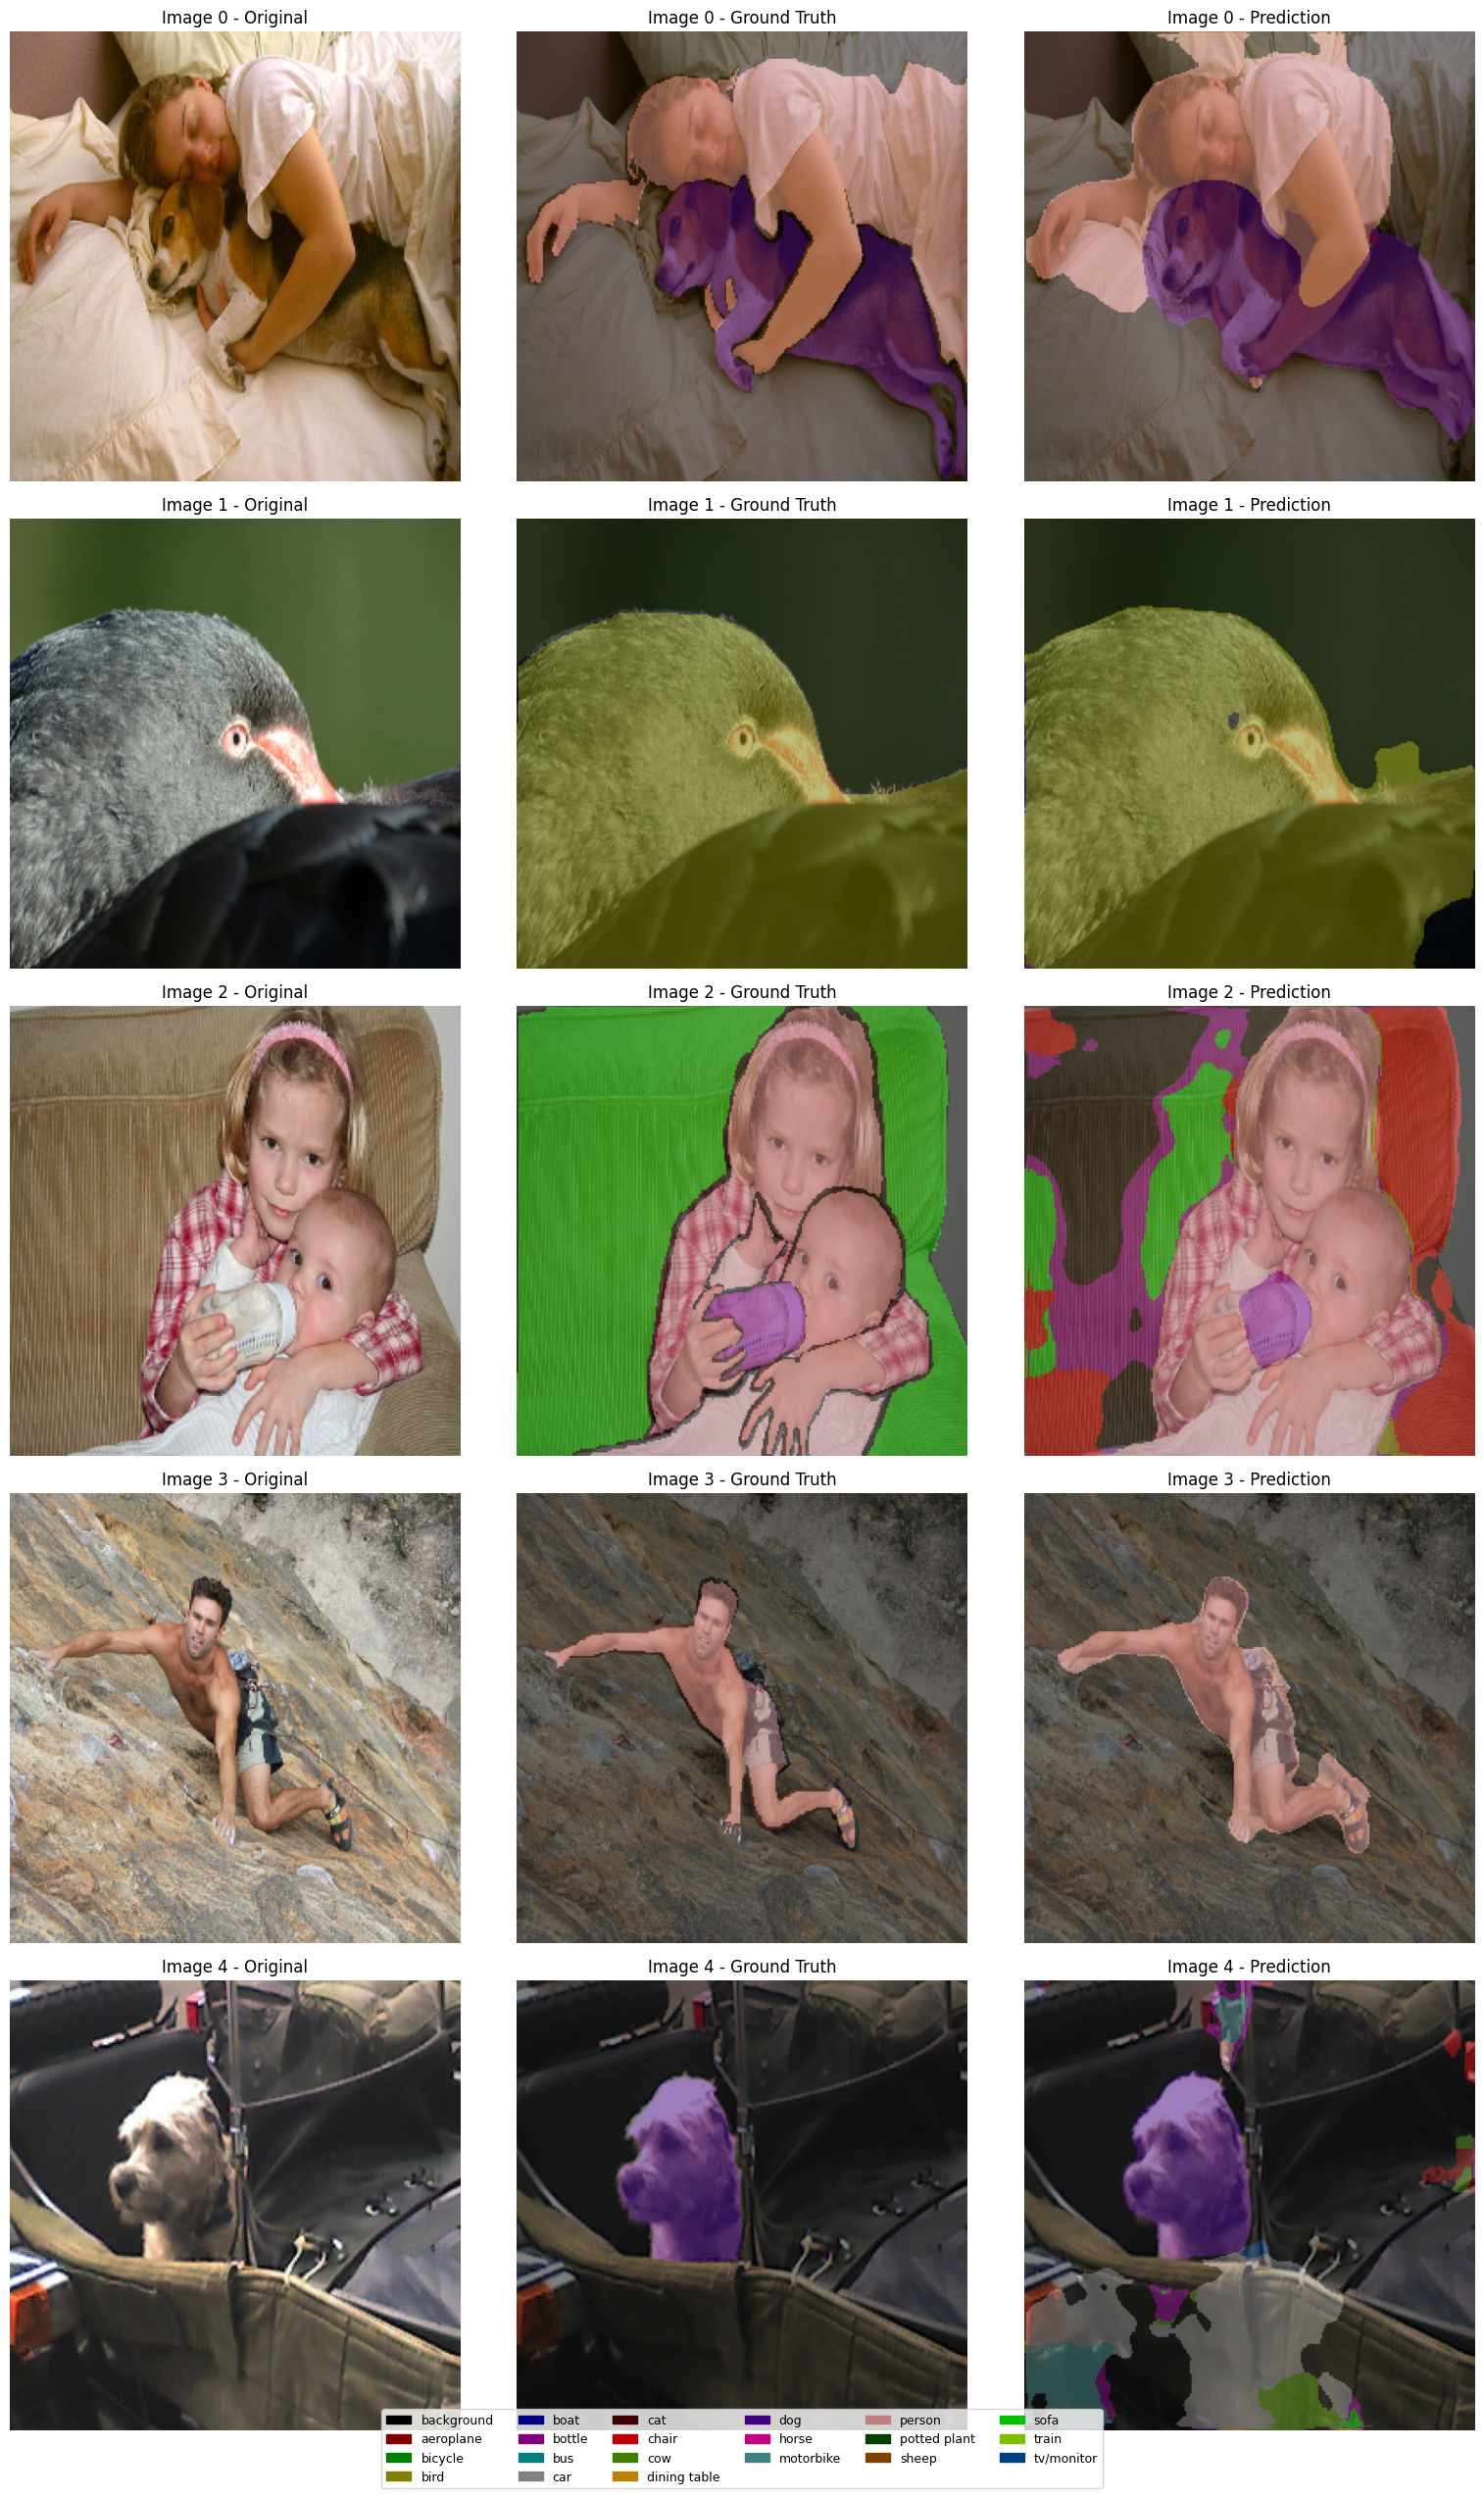

In [ ]:
VOC_COLORMAP = np.array([
    [0, 0, 0],         # background
    [128, 0, 0],       # aeroplane
    [0, 128, 0],       # bicycle
    [128, 128, 0],     # bird
    [0, 0, 128],       # boat
    [128, 0, 128],     # bottle
    [0, 128, 128],     # bus
    [128, 128, 128],   # car
    [64, 0, 0],        # cat
    [192, 0, 0],       # chair
    [64, 128, 0],      # cow
    [192, 128, 0],     # dining table
    [64, 0, 128],      # dog
    [192, 0, 128],     # horse
    [64, 128, 128],    # motorbike
    [192, 128, 128],   # person
    [0, 64, 0],        # potted plant
    [128, 64, 0],      # sheep
    [0, 192, 0],       # sofa
    [128, 192, 0],     # train
    [0, 64, 128]       # tv/monitor
])

# Class names (VOC)
VOC_CLASSES = [
    "background","aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow","dining table","dog",
    "horse","motorbike","person","potted plant","sheep",
    "sofa","train","tv/monitor"
]


def denormalize(image, mean, std):
    image = image.copy()
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image


def decode_segmentation(mask, colormap):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls in range(len(colormap)):
        rgb[mask == cls] = colormap[cls]
    return rgb


def overlay_mask(image, mask_rgb, alpha=0.5):
    image_uint8 = (image * 255).astype(np.uint8)

    return cv2.addWeighted(
        image_uint8,
        1 - alpha,
        mask_rgb,
        alpha,
        0
    )

# ----------------------------
# LOAD BATCH
# ----------------------------
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

# normalization values (ImageNet)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])


num_images = 5
fig, axes = plt.subplots(num_images, 3, figsize=(16, 5 * num_images))

for idx in range(num_images):

    image = images[idx].cpu().permute(1, 2, 0).numpy()
    true_mask = masks[idx].cpu().numpy()
    pred_mask = preds[idx].cpu().numpy()

    image = denormalize(image, mean, std)

    true_mask_rgb = decode_segmentation(true_mask, VOC_COLORMAP)
    pred_mask_rgb = decode_segmentation(pred_mask, VOC_COLORMAP)

    true_overlay = overlay_mask(image, true_mask_rgb)
    pred_overlay = overlay_mask(image, pred_mask_rgb)

    axes[idx, 0].imshow(image)
    axes[idx, 0].set_title(f"Image {idx} - Original")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(true_overlay)
    axes[idx, 1].set_title(f"Image {idx} - Ground Truth")
    axes[idx, 1].axis("off")

    axes[idx, 2].imshow(pred_overlay)
    axes[idx, 2].set_title(f"Image {idx} - Prediction")
    axes[idx, 2].axis("off")


legend_patches = [
    Patch(color=np.array(color)/255.0, label=cls)
    for cls, color in zip(VOC_CLASSES, VOC_COLORMAP)
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=6,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.show()

In [26]:
def get_confusion_matrix(model, loader, device, num_classes=21, ignore_index=255):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)          # [B, C, H, W]
            preds = torch.argmax(outputs, dim=1)  # [B, H, W]

            preds = preds.view(-1)
            masks = masks.view(-1)

            valid = masks != ignore_index
            preds = preds[valid].cpu().numpy()
            masks = masks[valid].cpu().numpy()

            y_pred.append(preds)
            y_true.append(masks)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return cm


def plot_confusion_matrix(cm, num_classes=21, normalize=True, class_names=None):
    if normalize:
        # Normalize per true class (row-wise), avoid division by zero
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_plot = np.where(row_sums == 0, 0, cm / row_sums)
        fmt = ".2f"
        title = "Confusion Matrix (Normalized)"
    else:
        cm_plot = cm
        fmt = "d"
        title = "Confusion Matrix"

    labels = class_names if class_names else list(range(num_classes))

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm_plot,                   # ← was missing!
        annot=num_classes <= 21,   # show numbers only if readable
        fmt=fmt,
        cmap="Blues",
        square=True,
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.3,
        linecolor="gray",
        cbar_kws={"shrink": 0.8}
    )
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

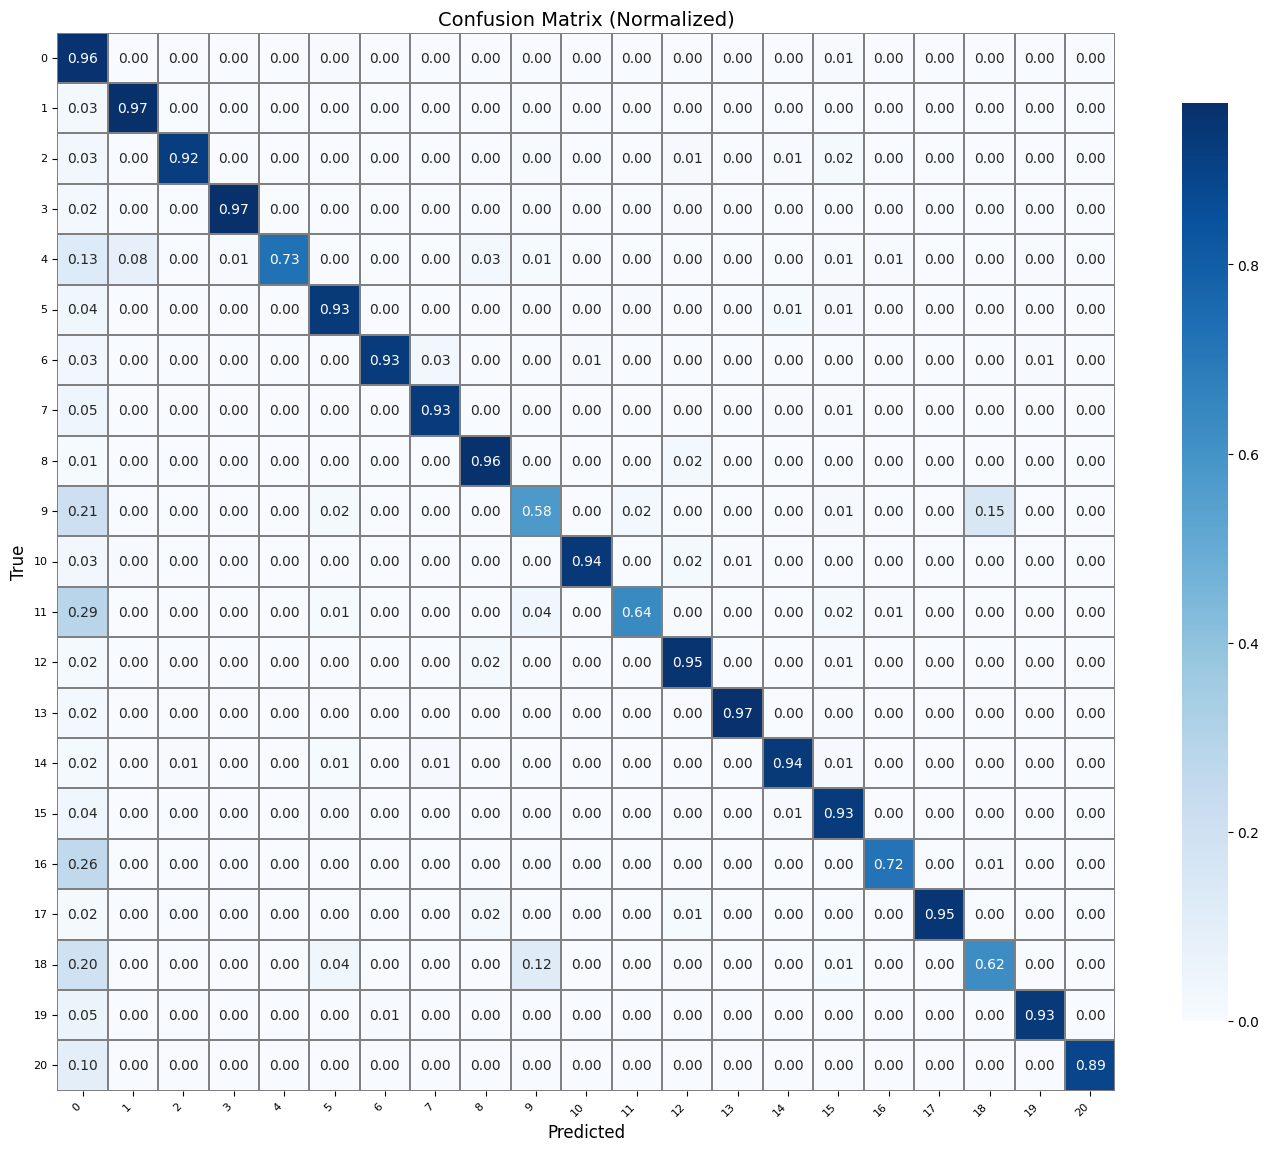

In [27]:
cm = get_confusion_matrix(model, val_loader, device, num_classes=21)
plot_confusion_matrix(cm, num_classes=21)

In [28]:
train_loss,train_dice_score=evaluate(model,train_loader, loss_fn, device)
print(f"Training Loss: {train_loss}, Training Dice Score: {train_dice_score}")
val_loss, val_dice_score = evaluate(model, val_loader, loss_fn, device)
print(f"Validation Loss: {val_loss}, Validation Dice Score: {val_dice_score}")

Training Loss: 0.22954080448202466, Training Dice Score: 0.7319122293721074
Validation Loss: 0.3347738164922465, Validation Dice Score: 0.6364840165428494
